In [1]:
from spin_lattices import KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import BooleanFourierAnalyser, keep_largest_n, ScorerType, get_scorer, SignalOption
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import lzma
from parity import popcount

%matplotlib widget

2023-01-23 14:18:59.747 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-23 14:18:59.750 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
2023-01-23 14:18:59.820 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
set_python_exception_handler ...


## How properties of Fourier spectra changes with the lattice size
1. How many elements of Fourier spectra are needed to achieve 95% overlap?
    - About 0.0007 of all, exponentially large with respect to number of spins
2. How fast the absolute value of Fourier coefficients decline comparing with the coefficients of the ground state in the ordinary basis.
    - Even slower
3. What happens if we keep elements of small degrees?
    - Nothing good
3. Which probability distribution is better to use?
    - Ground state distribution is slightly better for overlap-95%, but absolutely worse for accuracy-80% (not achievable)

In [20]:
def how_many_terms_to_achieve_score(
    analyzer: BooleanFourierAnalyser,
    scorer: str | ScorerType = "overlap",
    target_score: float = 0.95,
    min_terms: int = 1,
    max_terms: int = 101,
    step: int = 10,
    show_progress: bool = True,
) -> int | None:
    """
    How many terms are needed to reconstruct the sign structure of the ground state
    with the given score?

    Parameters
    ----------
    analyzer : BooleanFourierAnalyser
        The analyzer to use.

    scorer : str | ScorerType, optional

    target_score : float, optional
        The target score, by default 0.95

    min_terms : int, optional
        The minimum number of terms to try, by default 1

    max_terms : int, optional
        The maximum number of terms to try, by default 101

    step : int, optional
        The step size, by default 10

    Returns
    -------
    int | None
        The number of terms needed to achieve the target score, or None if the target
        score could not be achieved.
    """

    evaluation_set = analyzer.system.basis.states
    prediction = np.zeros_like(evaluation_set, dtype="float64")
    state_info_df = batched_state_info_df(
        analyzer.system.basis, analyzer.system.canonical_basis.states
    )

    for n_terms in range(min_terms, max_terms, step):
        if n_terms == min_terms:
            analyzer.set_truncate_strategy(keep_largest_n(n_terms))
        else:
            analyzer.set_truncate_strategy(keep_largest_n(step, offset=max(0, n_terms - step)))

        prediction += analyzer.predict(evaluation_set)

        true = analyzer._get_signal_df(analyzer.system.canonical_basis.states)
        prediction_expanded = np.asarray(
            state_info_df.merge(
                pd.Series(prediction, name="prediction", index=evaluation_set),
                left_on="representative",
                right_index=True,
                how="left",
            )["prediction"].values
        )
        if analyzer.signal_opt.kind == "sign" or analyzer.signal_opt.kind == "amplitude_median_bin":
            prediction_expanded = np.sign(prediction_expanded)
        score = get_scorer(scorer)(true, prediction_expanded)
        if show_progress:
            print(f"{n_terms} terms: {score:.3f}")
        if score >= target_score:
            return n_terms
    return None


In [4]:
# Marshall

analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=Path("groundstates"),
    ),
    use_subset_symmetries=True,
)
analyzer.fit(analyzer.system.canonical_basis.states)

assert how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=0.99) == 1
assert how_many_terms_to_achieve_score(analyzer, scorer="overlap", target_score=0.99) == 1
assert how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=1.01) is None

# Frustrated

analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0.8,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=Path("groundstates"),
    ),
    use_subset_symmetries=True,
)
analyzer.fit(analyzer.system.canonical_basis.states)


def assert_is_large(terms: int | None):
    if terms is not None:
        assert terms > 1


assert_is_large(how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=0.99))
assert_is_large(how_many_terms_to_achieve_score(analyzer, scorer="overlap", target_score=0.99))


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099
1 terms: 1.000
1 terms: 1.000
1 terms: 1.000
11 terms: 1.000
21 terms: 1.000
31 terms: 1.000
41 terms: 1.000
51 terms: 1.000
61 terms: 1.000
71 terms: 1.000
81 terms: 1.000
91 terms: 1.000
number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253
1 terms: 0.450
11 terms: 0.719
21 terms: 0.762
31 terms: 0.784
41 terms: 0.813
51 terms: 0.831
61 terms: 0.843
71 terms: 0.859
81 terms: 0.856
91 terms: 0.863
1 terms: 0.413
11 terms: 0.937
21 terms: 0.945
31 terms: 0.964
41 terms: 0.976
51 terms: 0.979
61 terms: 0.986
71 terms: 0.989
81 terms: 0.990
91 terms: 0.991


In [3]:
def get_analyzer_from_pickle(J2, experiment_dir):
    analyzer = BooleanFourierAnalyser(
        system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=4),
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=Path("groundstates"),
        ),
        use_subset_symmetries=True,
        show_progress=True,
    )
    analyzer.restore_learner_from_pickle(experiment_dir / f"learner-J2={J2!r}.pickle.lz")
    return analyzer


In [5]:
experiment_dir = Path("experiments/kagome24-2023-01-19")

J2s = sorted(
    [
        float(parse.search("learner-J2={}.pickle.lz", str(file)).fixed[0])
        for file in experiment_dir.glob("learner-J2=*.pickle.lz")
    ]
)

J2_to_analyzer = {J2: get_analyzer_from_pickle(J2, experiment_dir) for J2 in J2s}


number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.5-True-1-1.pickle
Ground state energy is -39.4742602743
number_spins=24
Symmetry group contains 16 elements


...

Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-1.pickle
Ground state energy is -41.5204728634
number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


In [8]:
results = []
for J2, analyzer in J2_to_analyzer.items():
    terms = how_many_terms_to_achieve_score(
        analyzer,
        scorer="overlap",
        target_score=0.95,
        step=10,
        max_terms=1001,
        show_progress=True,
    )
    results.append(dict(J2=J2, terms=terms, height=4, number_spins=analyzer.system.number_spins))
results_df = pd.DataFrame(results)


1 terms: 1.000
1 terms: 0.380
11 terms: 0.667
21 terms: 0.709
31 terms: 0.792
41 terms: 0.878
51 terms: 0.941
61 terms: 0.944
71 terms: 0.949
81 terms: 0.953
1 terms: 0.367
11 terms: 0.376
21 terms: 0.658
31 terms: 0.817
41 terms: 0.839
51 terms: 0.907
61 terms: 0.922
71 terms: 0.938
81 terms: 0.935
91 terms: 0.939
101 terms: 0.947
111 terms: 0.951
1 terms: 0.313
11 terms: 0.352
21 terms: 0.586
31 terms: 0.711
41 terms: 0.809
51 terms: 0.875
61 terms: 0.916
71 terms: 0.930
81 terms: 0.944
91 terms: 0.947
101 terms: 0.947
111 terms: 0.940
121 terms: 0.940
131 terms: 0.948
141 terms: 0.953
1 terms: 0.244
11 terms: 0.602
21 terms: 0.702
31 terms: 0.794
41 terms: 0.824
51 terms: 0.887
61 terms: 0.892
71 terms: 0.913
81 terms: 0.925
91 terms: 0.935
101 terms: 0.945
111 terms: 0.945
121 terms: 0.949
131 terms: 0.951
1 terms: 0.300
11 terms: 0.635
21 terms: 0.706
31 terms: 0.752
41 terms: 0.798
51 terms: 0.847
61 terms: 0.862
71 terms: 0.892
81 terms: 0.915
91 terms: 0.928
101 terms: 0.933
11

In [3]:
def batch_how_many_terms(
    height,
    J2s,
    target_score,
    scorer,
    max_terms,
    step,
    signal_opt=SignalOption(),
    J2_to_analyzer=None,
):
    results = []
    for J2 in J2s:
        if J2_to_analyzer is not None:
            analyzer = J2_to_analyzer[J2]
        else:
            analyzer = BooleanFourierAnalyser(
                system=HeisenbergJ1J2(
                    KagomeLattice(width=2, height=height),
                    J1=1,
                    J2=J2,
                    use_symmetries=True,
                    spin_inversion=1,
                    ground_state_cache_dir=Path("groundstates"),
                ),
                use_subset_symmetries=True,
                show_progress=True,
            )
            analyzer.fit(analyzer.system.canonical_basis.states, signal_opt=signal_opt)
        terms = how_many_terms_to_achieve_score(
            analyzer,
            scorer=scorer,
            target_score=target_score,
            step=step,
            max_terms=max_terms,
            show_progress=True,
        )
        if terms is not None:
            mean_hamming_weight = (
                pd.DataFrame(
                    keep_largest_n(terms)(analyzer.learner.get_coeffs_ser()).index,
                    columns=['subset']
                )
                .assign(hamming_weight=lambda x: popcount(x["subset"]))
                .assign(
                    subset=lambda x: np.where(
                        x["hamming_weight"] > analyzer.system.number_spins // 2,
                        x["subset"] ^ (2**analyzer.system.number_spins - 1),
                        x["subset"],
                    )
                )
                .assign(hamming_weight=lambda x: popcount(x["subset"]))["hamming_weight"]
                .mean()
            )
        else:
            mean_hamming_weight = None
        results.append(
            dict(
                J2=J2,
                terms=terms,
                height=height,
                number_spins=analyzer.system.number_spins,
                mean_hamming_weight=mean_hamming_weight,
            )
        )
    return pd.DataFrame(results)


In [77]:
J2s = [0., 0.3, 0.6, 0.8]
results_df = pd.concat(
    [
        batch_how_many_terms(
            height, J2s, target_score=0.95, scorer="overlap", max_terms=1001, step=1
        )
        for height in [3]
    ]
)


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253


100%|██████████| 487/487 [00:01<00:00, 348.09it/s]


1 terms: 0.413
2 terms: 0.413
3 terms: 0.522
4 terms: 0.522
5 terms: 0.669
6 terms: 0.706
7 terms: 0.809
8 terms: 0.886
9 terms: 0.900
10 terms: 0.893
11 terms: 0.937
12 terms: 0.924
13 terms: 0.933
14 terms: 0.911
15 terms: 0.925
16 terms: 0.950


In [79]:
results_df

,J2,terms,height,number_spins,mean_hamming_weight
0,0.0,1,3,18,6.000000
1,0.3,1,3,18,6.000000
2,0.6,7,3,18,7.428571
3,0.8,16,3,18,7.500000


In [23]:
J2s = [0., 0.3, 0.6, 0.8]
results_df_amplitude = pd.concat(
    [
        batch_how_many_terms(
            height, J2s, target_score=0.95, scorer="overlap", max_terms=5001, step=1,
            signal_opt=SignalOption(kind="sign")
        )
        for height in [3]
    ]
)


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253


100%|██████████| 487/487 [00:01<00:00, 347.89it/s]


1 terms: 0.413
2 terms: 0.413
3 terms: 0.522
4 terms: 0.522
5 terms: 0.669
6 terms: 0.706
7 terms: 0.809
8 terms: 0.886
9 terms: 0.900
10 terms: 0.893
11 terms: 0.937
12 terms: 0.924
13 terms: 0.933
14 terms: 0.911
15 terms: 0.925
16 terms: 0.950


In [24]:
results_df_amplitude

,J2,terms,height,number_spins,mean_hamming_weight
0,0.0,1,3,18,6.000000
1,0.3,1,3,18,6.000000
2,0.6,7,3,18,7.428571
3,0.8,16,3,18,7.500000


In [16]:
results_df_amplitude

,J2,terms,height,number_spins,mean_hamming_weight
0,0.0,1,2,12,4.0
1,0.3,1,2,12,4.0
2,0.6,1,2,12,4.0
3,0.8,4,2,12,5.5


In [11]:
1331 * 6.78 / (31 * 7.68)

37.90398185483871

In [17]:
46 * 4.4 / (4 * 5.5)

9.200000000000001

In [11]:
results_full = pd.concat(
    [
        results_df,
        results_df_small,
    ]
)


In [12]:
%matplotlib inline

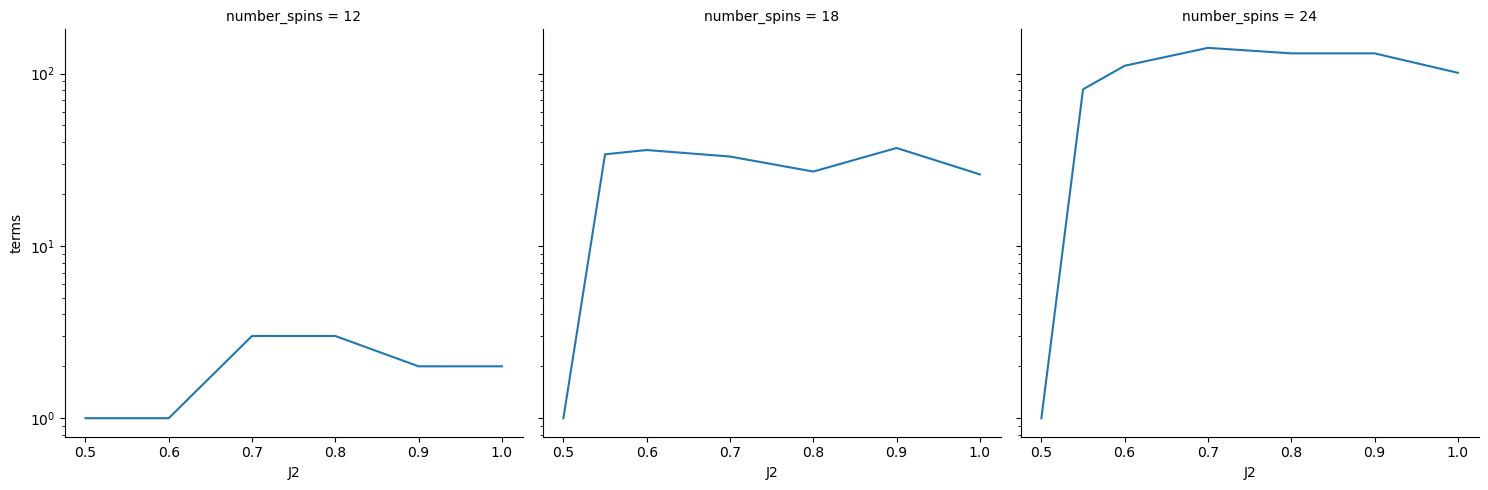

In [15]:
g = sns.relplot(data=results_full, x="J2", y="terms", col="number_spins", kind="line")
# make y axis log scale
g.set(yscale="log")


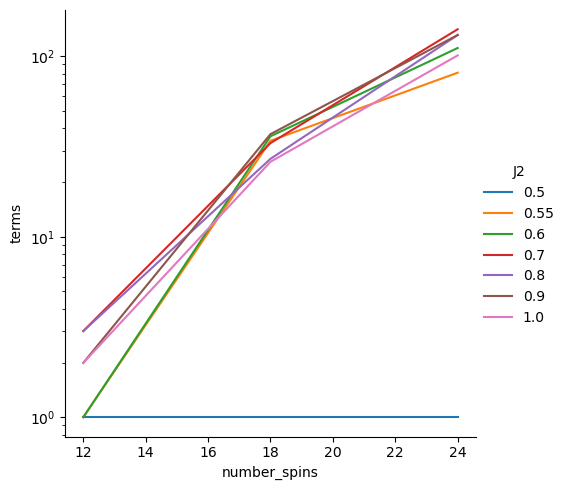

In [16]:
sns.relplot(
    data=results_full.assign(J2=lambda x: x["J2"].astype("str")),
    x="number_spins",
    y="terms",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [21]:
uniform_vs_prob_accuracy = pd.concat(
    [
        batch_how_many_terms(
            3,
            J2s,
            target_score=0.8,
            scorer="accuracy",
            max_terms=1001,
            step=1,
            signal_opt=SignalOption(weights=weights),
        ).assign(weights=weights)
        for weights in ["none", "prob"]
    ]
)


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.5-True-1-1.pickle
Ground state energy is -29.6279366224


...

Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 345.91it/s]


1 terms: 0.536
2 terms: 0.536
3 terms: 0.545
4 terms: 0.542
5 terms: 0.567
6 terms: 0.564
7 terms: 0.569
8 terms: 0.568
9 terms: 0.571
10 terms: 0.582
11 terms: 0.586
12 terms: 0.593
13 terms: 0.595
14 terms: 0.603
15 terms: 0.605
16 terms: 0.610
17 terms: 0.619
18 terms: 0.623
19 terms: 0.642
20 terms: 0.639
21 terms: 0.653
22 terms: 0.658
23 terms: 0.657
24 terms: 0.648
25 terms: 0.661
26 terms: 0.662
27 terms: 0.663
28 terms: 0.669
29 terms: 0.661
30 terms: 0.679
31 terms: 0.685
32 terms: 0.681
33 terms: 0.693
34 terms: 0.686
35 terms: 0.695
36 terms: 0.700
37 terms: 0.698
38 terms: 0.695
39 terms: 0.702
40 terms: 0.708
41 terms: 0.704
42 terms: 0.701
43 terms: 0.698
44 terms: 0.697
45 terms: 0.690
46 terms: 0.704
47 terms: 0.710
48 terms: 0.691
49 terms: 0.688
50 terms: 0.684
51 terms: 0.692
52 terms: 0.682
53 terms: 0.681
54 terms: 0.681
55 terms: 0.677
56 terms: 0.680
57 terms: 0.676
58 terms: 0.683
59 terms: 0.681
60 terms: 0.692
61 terms: 0.692
62 terms: 0.686
63 terms: 0.681
6

In [23]:
uniform_vs_prob_accuracy


,J2,terms,height,number_spins,weights
0,0.50,1.0,3,18,none
1,0.55,14.0,3,18,none
2,0.60,17.0,3,18,none
3,0.70,22.0,3,18,none
4,0.80,35.0,3,18,none
5,0.90,50.0,3,18,none
6,1.00,46.0,3,18,none
0,0.50,1.0,3,18,prob
1,0.55,NaN,3,18,prob
2,0.60,NaN,3,18,prob


In [110]:
mean_abs_coeffs = {
    J2: analyzer.learner.get_coeffs_ser()
    .to_frame()
    .assign(
        hamming_weight=lambda x: popcount(x.index),
        abs_coeff=lambda x: x["coeff"].abs(),
    )
    .reset_index()
    .rename(columns={"index": "state"})
    .assign(
        state=lambda x: np.where(
            x["hamming_weight"] > analyzer.system.number_spins // 2,
            x["state"] ^ (2**analyzer.system.number_spins - 1),
            x["state"],
        )
    )
    .assign(hamming_weight=lambda x: popcount(x["state"]))
    .set_index("state")
    .groupby("hamming_weight")["abs_coeff"]
    .mean()
    for J2, analyzer in J2_to_analyzer.items()
}


In [75]:
%matplotlib inline

<AxesSubplot: xlabel='hamming_weight'>

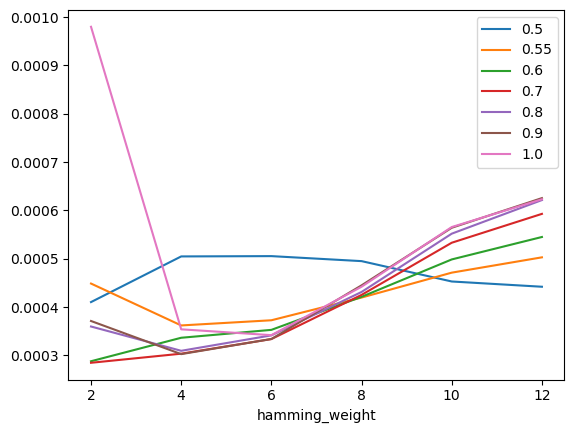

In [117]:
pd.DataFrame(mean_abs_coeffs)[lambda x: x.index % 2 == 0].drop([0]).plot()


In [11]:
hmt_value_3 = batch_how_many_terms(
    height=3,
    J2s=np.arange(0, 1.1, 0.1),
    target_score=0.95,
    scorer="value_overlap",
    max_terms=10001,
    step=10,
    signal_opt=SignalOption(kind="value"),
)


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 365.32it/s]


1 terms: 0.030
11 terms: 0.178
21 terms: 0.336
31 terms: 0.430
41 terms: 0.503
51 terms: 0.555
61 terms: 0.595
71 terms: 0.627
81 terms: 0.652
91 terms: 0.674
101 terms: 0.694
111 terms: 0.714
121 terms: 0.731
131 terms: 0.746
141 terms: 0.760
151 terms: 0.774
161 terms: 0.786
171 terms: 0.797
181 terms: 0.806
191 terms: 0.816
201 terms: 0.824
211 terms: 0.832
221 terms: 0.840
231 terms: 0.847
241 terms: 0.853
251 terms: 0.859
261 terms: 0.865
271 terms: 0.870
281 terms: 0.876
291 terms: 0.881
301 terms: 0.886
311 terms: 0.890
321 terms: 0.895
331 terms: 0.899
341 terms: 0.903
351 terms: 0.907
361 terms: 0.911
371 terms: 0.914
381 terms: 0.917
391 terms: 0.921
401 terms: 0.923
411 terms: 0.926
421 terms: 0.928
431 terms: 0.931
441 terms: 0.934
451 terms: 0.936
461 terms: 0.938
471 terms: 0.940
481 terms: 0.942
491 terms: 0.944
501 terms: 0.946
511 terms: 0.948
521 terms: 0.949
531 terms: 0.951


<AxesSubplot: xlabel='J2', ylabel='terms'>

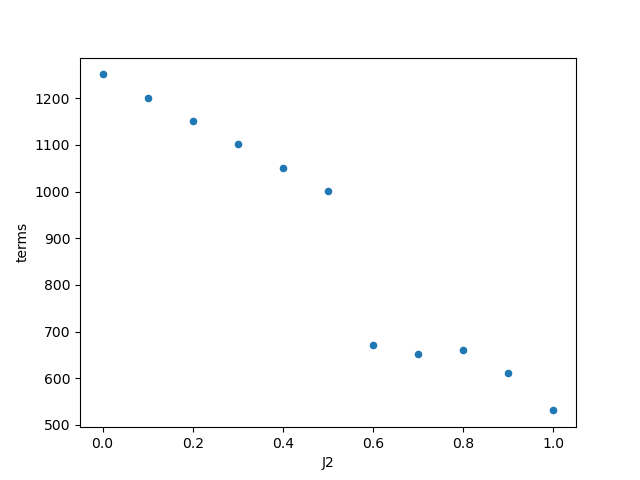

In [19]:
hmt_value_3.plot(x="J2", y="terms", kind="scatter")


In [4]:
hmt_amplitude_3 = batch_how_many_terms(
    height=3,
    J2s=np.arange(0, 1.1, 0.1),
    target_score=0.95,
    scorer="value_overlap",
    max_terms=10001,
    step=10,
    signal_opt=SignalOption(kind="amplitude"),
)


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 360.79it/s]


1 terms: 0.082
11 terms: 0.325
21 terms: 0.403
31 terms: 0.456
41 terms: 0.490
51 terms: 0.525
61 terms: 0.553
71 terms: 0.577
81 terms: 0.596
91 terms: 0.613
101 terms: 0.628
111 terms: 0.641
121 terms: 0.654
131 terms: 0.665
141 terms: 0.675
151 terms: 0.686
161 terms: 0.696
171 terms: 0.706
181 terms: 0.714
191 terms: 0.723
201 terms: 0.731
211 terms: 0.738
221 terms: 0.745
231 terms: 0.752
241 terms: 0.758
251 terms: 0.765
261 terms: 0.771
271 terms: 0.777
281 terms: 0.782
291 terms: 0.788
301 terms: 0.793
311 terms: 0.797
321 terms: 0.802
331 terms: 0.807
341 terms: 0.811
351 terms: 0.815
361 terms: 0.819
371 terms: 0.823
381 terms: 0.827
391 terms: 0.830
401 terms: 0.834
411 terms: 0.838
421 terms: 0.841
431 terms: 0.845
441 terms: 0.847
451 terms: 0.850
461 terms: 0.853
471 terms: 0.856
481 terms: 0.859
491 terms: 0.862
501 terms: 0.864
511 terms: 0.867
521 terms: 0.870
531 terms: 0.872
541 terms: 0.874
551 terms: 0.877
561 terms: 0.879
571 terms: 0.881
581 terms: 0.883
591 term

<AxesSubplot: xlabel='J2'>

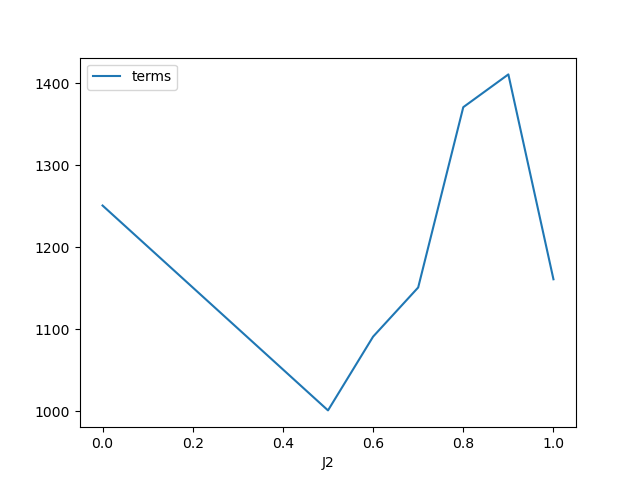

In [6]:
hmt_amplitude_3.plot(x="J2", y="terms", kind="line")


In [2]:
def get_mean_abs_coeffs(kind, J2s):
    results = {}
    height = 3
    for J2 in J2s:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                KagomeLattice(width=2, height=height),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
                ground_state_cache_dir=Path("groundstates"),
            ),
            use_subset_symmetries=True,
            show_progress=True,
        )
        analyzer.fit(analyzer.system.canonical_basis.states, signal_opt=SignalOption(kind=kind))

        mean_abs_coeff = (
            analyzer.learner.get_coeffs_ser()
            .to_frame()
            .assign(
                hamming_weight=lambda x: popcount(x.index),
                abs_coeff=lambda x: x["coeff"].abs(),
            )
            .reset_index()
            .rename(columns={"index": "state"})
            .assign(
                state=lambda x: np.where(
                    x["hamming_weight"] > analyzer.system.number_spins // 2,
                    x["state"] ^ (2**analyzer.system.number_spins - 1),
                    x["state"],
                )
            )
            .assign(hamming_weight=lambda x: popcount(x["state"]))
            .set_index("state")
            .groupby("hamming_weight")["abs_coeff"]
            .mean()
        )
        results[J2] = mean_abs_coeff
    return results


In [31]:
mean_abs_coeff_sign = get_mean_abs_coeffs("sign", J2s=np.arange(0, 1.1, 0.1))


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

100%|██████████| 487/487 [00:01<00:00, 288.08it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 308.79it/s]


In [35]:
pd.DataFrame(mean_abs_coeff_sign)


,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
hamming_weight,,,,,,,,,,,
0,0.004525,0.004525,0.004525,0.004525,0.000411,0.005019,0.004031,0.006006,0.004689,0.009626,0.004031
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.004889,0.004889,0.004889,0.004767,0.004118,0.003884,0.002949,0.002888,0.003148,0.003191,0.002498
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.004704,0.004704,0.004704,0.004652,0.004456,0.004274,0.003378,0.003534,0.003223,0.003060,0.003110
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.004722,0.004722,0.004722,0.004653,0.004563,0.004458,0.003870,0.003828,0.004010,0.003828,0.003933
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.003865,0.003865,0.003865,0.003821,0.003773,0.003700,0.004129,0.004251,0.004611,0.004922,0.004812


<AxesSubplot: xlabel='hamming_weight'>

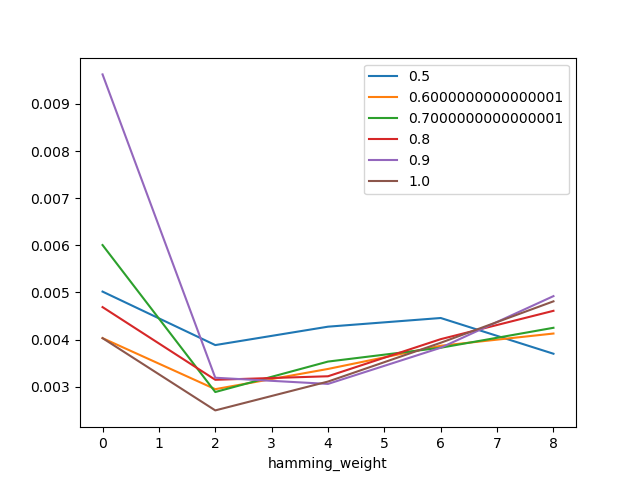

In [39]:
pd.DataFrame(mean_abs_coeff_sign).iloc[:, 5:][lambda x: x.index % 2 == 0].plot()


In [40]:
mean_abs_coeff_value = get_mean_abs_coeffs("value", J2s=np.arange(0, 1.1, 0.1))


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

100%|██████████| 487/487 [00:01<00:00, 306.47it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 366.72it/s]


<AxesSubplot: xlabel='hamming_weight'>

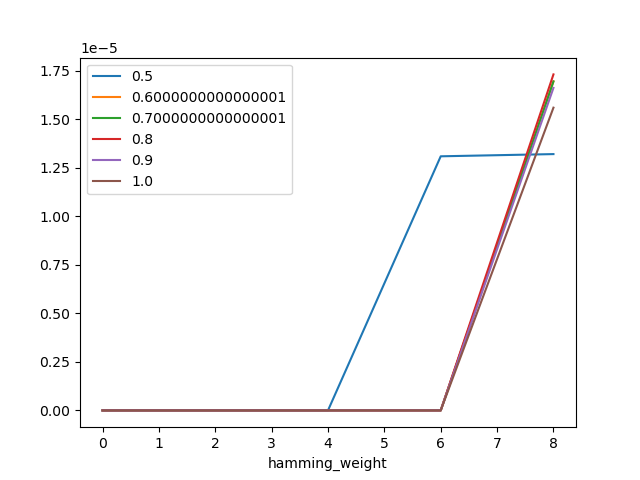

In [41]:
pd.DataFrame(mean_abs_coeff_value).iloc[:, 5:][lambda x: x.index % 2 == 0].plot()


In [42]:
mean_abs_coeff_amplitude = get_mean_abs_coeffs("amplitude", J2s=np.arange(0, 1.1, 0.1))


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

100%|██████████| 487/487 [00:01<00:00, 361.30it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 364.02it/s]


<AxesSubplot: xlabel='hamming_weight'>

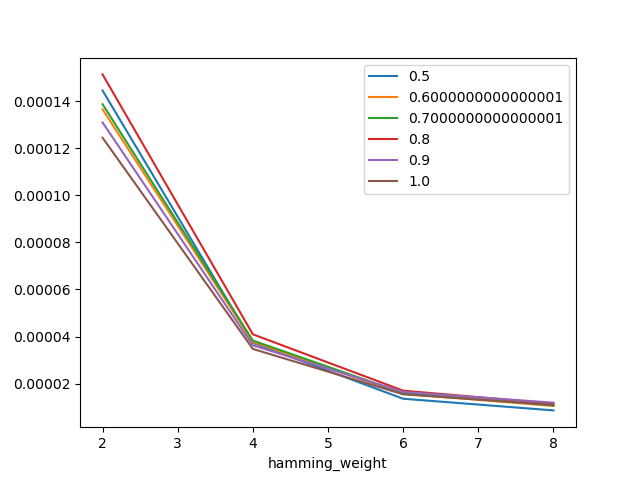

In [46]:
pd.DataFrame(mean_abs_coeff_amplitude).iloc[:, 5:][lambda x: x.index % 2 == 0].drop([0]).plot()


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


100%|██████████| 487/487 [00:01<00:00, 350.73it/s]


<AxesSubplot: xlabel='hamming_weight'>

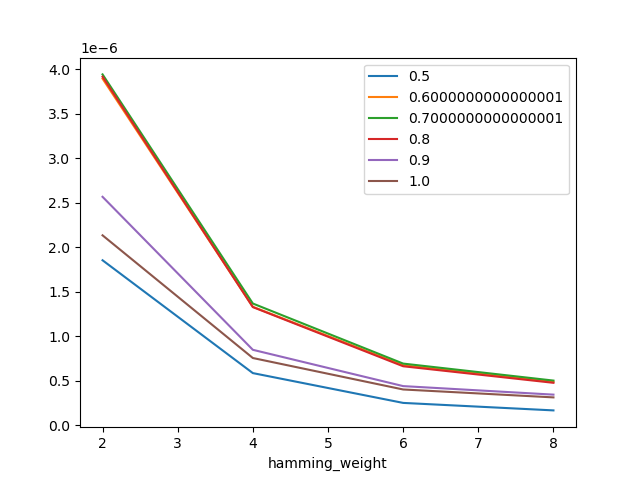

In [3]:
pd.DataFrame(get_mean_abs_coeffs("prob", J2s=np.arange(0, 1.1, 0.1))).iloc[:, 5:][
    lambda x: x.index % 2 == 0
].drop([0]).plot()


In [18]:
def get_sum_square_coeffs(kind, J2s):
    results = {}
    height = 3
    for J2 in J2s:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                KagomeLattice(width=2, height=height),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
                ground_state_cache_dir=Path("groundstates"),
            ),
            use_subset_symmetries=True,
            show_progress=True,
        )
        analyzer.fit(analyzer.system.canonical_basis.states, signal_opt=SignalOption(kind=kind))

        mean_abs_coeff = (
            analyzer.learner.get_coeffs_ser()
            .to_frame()
            .assign(
                hamming_weight=lambda x: popcount(x.index),
                square=lambda x: x["coeff"] ** 2,
            )
            .reset_index()
            .rename(columns={"index": "state"})
            .assign(
                state=lambda x: np.where(
                    x["hamming_weight"] > analyzer.system.number_spins // 2,
                    x["state"] ^ (2**analyzer.system.number_spins - 1),
                    x["state"],
                )
            )
            .assign(hamming_weight=lambda x: popcount(x["state"]))
            .set_index("state")
            .groupby("hamming_weight")["square"]
            .sum()
        )
        results[J2] = mean_abs_coeff
    return results


In [19]:
pd.DataFrame(get_sum_square_coeffs("prob", J2s=[0., 0.3, 0.6, 0.8, 0.1]))[
    lambda x: x.index % 2 == 0
]


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


100%|██████████| 487/487 [00:01<00:00, 263.59it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.3-True-1-1.pickle
Ground state energy is -31.5823856157


...

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.1-True-1-1.pickle
Ground state energy is -33.6040689825


100%|██████████| 487/487 [00:01<00:00, 256.81it/s]


,0.0,0.3,0.6,0.8,0.1
hamming_weight,,,,,
0,4.230290e-10,4.230290e-10,4.230290e-10,4.230290e-10,4.230290e-10
2,1.213190e-10,1.347257e-10,6.201485e-10,5.494613e-10,1.252769e-10
4,2.151914e-10,2.649515e-10,1.610911e-09,1.391515e-09,2.293687e-10
6,1.771415e-10,2.292762e-10,3.013299e-09,2.506727e-09,1.917244e-10
8,1.622655e-10,2.181378e-10,4.048820e-09,3.324407e-09,1.774944e-10


In [21]:
%matplotlib inline

number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

100%|██████████| 487/487 [00:01<00:00, 302.14it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.1-True-1-1.pickle
Ground state energy is -33.6040689825


100%|██████████| 487/487 [00:01<00:00, 305.13it/s]


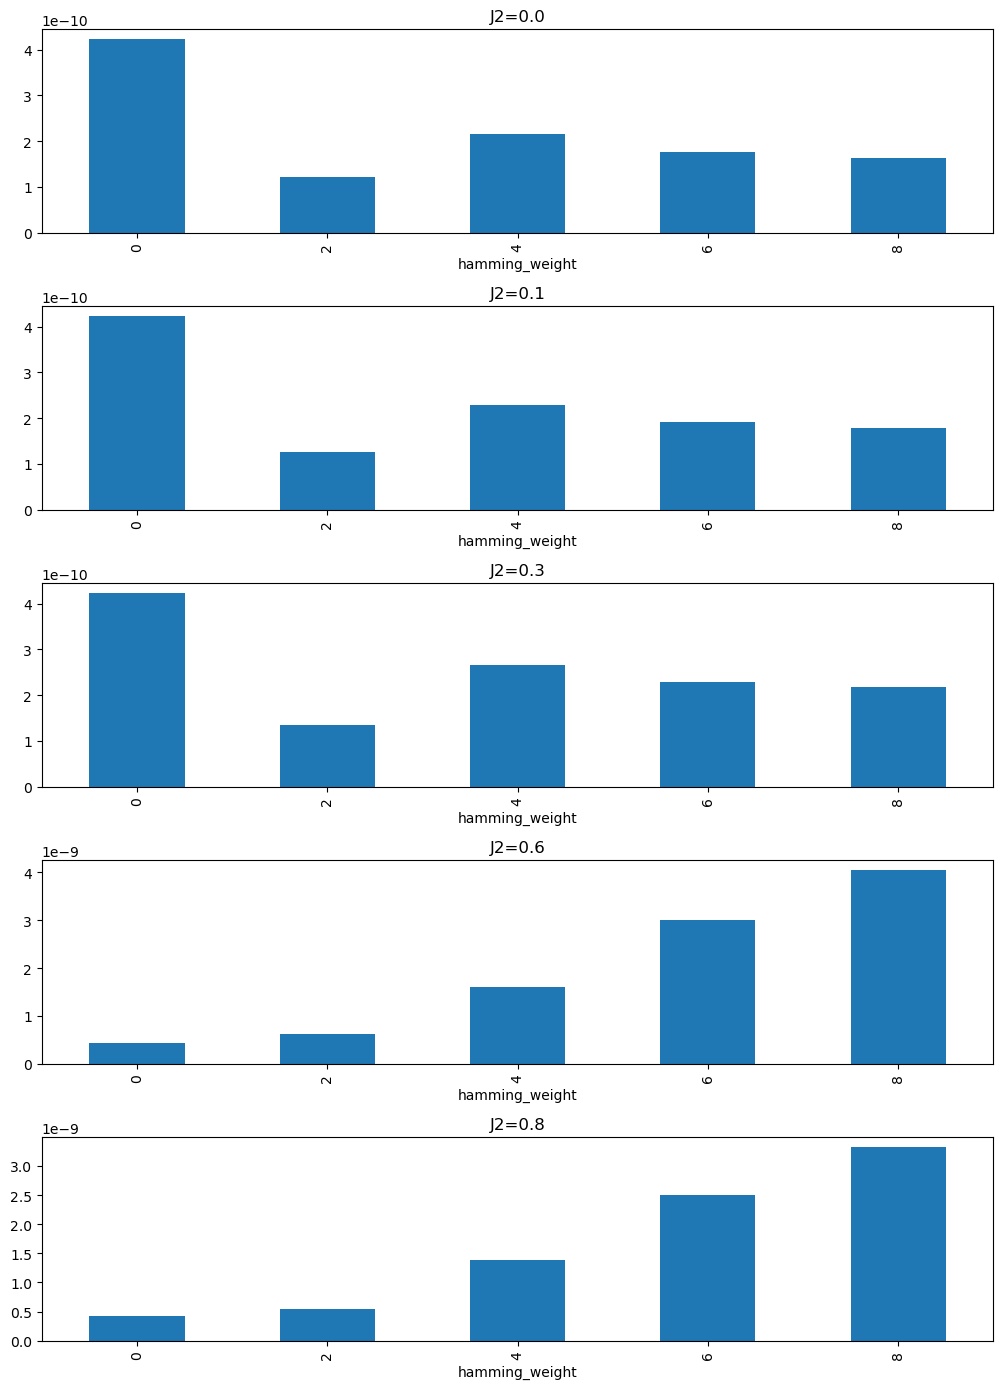

In [44]:
coeff_distribution = pd.DataFrame(get_sum_square_coeffs("prob", J2s=[0., 0.3, 0.6, 0.8, 0.1]))[
    lambda x: x.index % 2 == 0
]

fig, axs = plt.subplots(nrows = len(coeff_distribution.T), figsize=(10, 14))
for (J2, distribution), ax in (zip(coeff_distribution.T.sort_index().iterrows(), axs)):
    distribution.plot.bar(label=J2, ax=ax)
    ax.set_title(f"{J2=}")
plt.tight_layout()

In [57]:
def get_subsets_with_large_coeff(kind, J2s, keep_largest):
    results = {}
    height = 3
    for J2 in J2s:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                KagomeLattice(width=2, height=height),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
                ground_state_cache_dir=Path("groundstates"),
            ),
            use_subset_symmetries=True,
            show_progress=True,
        )
        analyzer.fit(analyzer.system.canonical_basis.states, signal_opt=SignalOption(kind=kind))
        results[J2] = keep_largest_n(keep_largest)(analyzer.learner.get_coeffs_ser()).index
    return results

In [58]:
subsets = 

number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

100%|██████████| 487/487 [00:01<00:00, 244.32it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253


100%|██████████| 487/487 [00:01<00:00, 285.62it/s]


In [71]:
number_spins = 18
pd.DataFrame(get_subsets_with_large_coeff("amplitude", J2s=[0., 0.3, 0.6, 0.8], keep_largest=50)).melt(var_name="J2", value_name="subset").assign(
    hamming_weight=lambda x: popcount(x["subset"])).assign(
    subset=lambda x: np.where(
        x["hamming_weight"] > number_spins // 2,
        x["subset"] ^ (2**number_spins - 1),
        x["subset"],
    )
).groupby("J2")["hamming_weight"].mean()


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253


100%|██████████| 487/487 [00:01<00:00, 354.16it/s]


J2
0.0    4.00
0.3    4.08
0.6    5.12
0.8    5.08
Name: hamming_weight, dtype: float64

In [70]:
number_spins = 18
pd.DataFrame(get_subsets_with_large_coeff("sign", J2s=[0., 0.3, 0.6, 0.8], keep_largest=50)).melt(var_name="J2", value_name="subset").assign(
    hamming_weight=lambda x: popcount(x["subset"])).assign(
    subset=lambda x: np.where(
        x["hamming_weight"] > number_spins // 2,
        x["subset"] ^ (2**number_spins - 1),
        x["subset"],
    )
).groupby("J2")["hamming_weight"].mean()


number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-1.pickle
Ground state energy is -34.6339591099


...

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.8-True-1-1.pickle
Ground state energy is -29.4963743253


100%|██████████| 487/487 [00:01<00:00, 355.87it/s]


J2
0.0    6.84
0.3    7.20
0.6    7.52
0.8    8.12
Name: hamming_weight, dtype: float64